# CycleGAN Artistic Style Transfer
*From Pixels to Brushstrokes: Transforming Photographs into Artist-Specific Paintings with CycleGANs*
___________

TIF360 - Advanced machine learning with neural networks: Project L

Ebba Gregefalk, Junyi Kuang, and Diana Lam


### General info

Transforms real-world photographs into paintings in the style of a chosen artist using CycleGANs.

When "original cycleGAN paper" is meantioned, it refers to the paper: https://arxiv.org/pdf/1703.10593 

## 1. Install & Import Dependencies

In [ ]:
# Install required packages 
# !pip install torch torchvision lpips scipy Pillow matplotlib tqdm

In [ ]:
import os
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils
from torchvision.models import inception_v3

# Evaluation libraries
import lpips
from scipy import linalg
from skimage.metrics import structural_similarity as ssim_metric

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f'Using device: {DEVICE}')

if DEVICE.type == "mps":
    print("Using Apple GPU (Metal/MPS)")
elif DEVICE.type == "cuda":
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: mps
Using Apple GPU (Metal/MPS)


## 2. Configuration

Key parameters that control training and evaluation. The datasets used are listed in the table below and were downloaded locally to the computer, orginized in different folders for each style/artist.

### Datasets used
| Style / Artist | Dataset | Link |
|-------------|-----------------|-------|
| Photographs | Flickr8k Dataset | https://www.kaggle.com/datasets/adityajn105/flickr8k |
| Albrecht Dürer | Best-Artworks-of-All-Time | https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time?resource=download |
| Vincent van Gogh | Best-Artworks-of-All-Time | https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time?resource=download |
| Claude Monet | Claude Monet pictorial works dataset (Wikiart) | https://www.kaggle.com/datasets/varnez/claude-monet-pictorial-works-dataset-wikiart |
| Edvard Munch | Edvard Munch Paintings | https://www.kaggle.com/datasets/isaienkov/edvard-munch-paintings |
| Roy Lichtenstein | Wikiart.org, Roy Lichtenstein: List of works - All Artworks | https://www.wikiart.org/en/roy-lichtenstein/all-works |
| Ghibli | Real to Ghibli Image Dataset (trainB_ghibli) | https://www.kaggle.com/datasets/shubham1921/real-to-ghibli-image-dataset-5k-paired-images |

In [ ]:
# CONFIGURATION  

# Artist selection
'''Set the selected artist and make sure a folder with the same name exists.'''
ARTIST = 'Vincent_van_Gogh'

# Dataset paths
BASE_DIR = Path().resolve()
PHOTO_DIR = BASE_DIR / "photographs/images"
PAINTING_DIR = BASE_DIR / f"best_artworks/images/images/{ARTIST}"

# Image counts (was set small to perform initial test runs, large to train properly)
NUM_PHOTOS = 400        # number of photos used for training
NUM_PAINTINGS = 400     # number of paintings used for training
NUM_TEST = 100          # held-out photos & paintings for evaluation

# Image preprocessing
IMG_SIZE = 256          # resize to IMG_SIZE × IMG_SIZE
CROP_SIZE = 256         # random crop during training (data augmentation)

# Training hyperparameters
BATCH_SIZE = 4          # increase if you have enough VRAM (8 or 16)
NUM_EPOCHS = 150        # was reduced for initial test runs
DECAY_EPOCH = 75        # epoch at which to start linearly decaying the LR 
LR = 2e-4               # initial learning rate
LAMBDA_CYCLE = 10.0     # cycle-consistency loss weight
LAMBDA_IDENTITY = 5.0   # identity loss weight (0 to disable), reducing this will result in less “copying input” and give stronger stylization (more painting-like)
POOL_SIZE = 50          # image history buffer size for discriminators
N_RES_BLOCKS = 9        # residual blocks in generator (6 for smaller images in the original cycleGAN paper)

# Output directories
OUT_DIR = BASE_DIR / f'output/{ARTIST}'
MODEL_DIR = OUT_DIR / 'models'
SAMPLE_DIR = OUT_DIR / 'samples'
EVAL_DIR = OUT_DIR / 'evaluation'

for d in [MODEL_DIR, SAMPLE_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Artist : {ARTIST}')
print(f'Photos : {NUM_PHOTOS} train + {NUM_TEST} test')
print(f'Paintings: {NUM_PAINTINGS} train + {NUM_TEST} test')
print(f'Epochs : {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  Image: {IMG_SIZE}px')

Artist : Vincent_van_Gogh
Photos : 400 train + 100 test
Paintings: 400 train + 100 test
Epochs : 150  |  Batch: 4  |  Image: 256px


## 3. Dataset & Preprocessing

In [ ]:
def load_image_paths(directory: Path, limit: int = None) -> list:
    '''Collect image file paths from a directory, optionally capping the count.'''
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths = [p for p in sorted(directory.iterdir()) if p.suffix.lower() in exts]
    random.shuffle(paths) # shuffle the paths to randomize the image order
    if limit:
        paths = paths[:limit]
    return paths


# Training transforms
'''Resize slightly larger, then random crop -> random horizontal flip -> normalise'''
train_transform = T.Compose([
    T.Resize(int(CROP_SIZE * 1.12), Image.BICUBIC),  # slight upscale for crop
    T.RandomCrop(CROP_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.05, contrast=0.05),   # mild colour augmentation
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # normalize to [-1, 1]
])

# Test / evaluation transforms (no random augmentation)
'''Resize and normalize'''
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class UnpairedDataset(Dataset):
    '''
    Unpaired (PyTorch) dataset for CycleGAN.
    Domain X = photographs, Domain Y = paintings.
    Images are sampled independently, there is no correspondence required.
    '''
    def __init__(self, x_paths: list, y_paths: list, transform=None):
        self.x_paths = x_paths  # photograph paths
        self.y_paths = y_paths  # painting paths
        self.transform = transform  # image transformations

    def __len__(self):
        return max(len(self.x_paths), len(self.y_paths))

    def _load(self, path: Path) -> Image.Image:
        img = Image.open(path).convert('RGB')
        return img

    def __getitem__(self, idx):
        x = self._load(self.x_paths[idx % len(self.x_paths)])
        y = self._load(self.y_paths[idx % len(self.y_paths)])
        if self.transform:
            x = self.transform(x)
            y = self.transform(y)
        return x, y


# Build path lists
all_photo_paths = load_image_paths(PHOTO_DIR)
all_painting_paths = load_image_paths(PAINTING_DIR)

# Train / test split, that reserves test images before training split
test_photo_paths = all_photo_paths[:NUM_TEST]
test_painting_paths = all_painting_paths[:NUM_TEST]
train_photo_paths = all_photo_paths[NUM_TEST: NUM_TEST + NUM_PHOTOS]
train_painting_paths = all_painting_paths[NUM_TEST: NUM_TEST + NUM_PAINTINGS]

print(f'Train photos    : {len(train_photo_paths)}')
print(f'Train paintings : {len(train_painting_paths)}')
print(f'Test photos     : {len(test_photo_paths)}')
print(f'Test paintings  : {len(test_painting_paths)}')

train_dataset = UnpairedDataset(train_photo_paths, train_painting_paths, train_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=0, pin_memory=True, drop_last=True) # num_workers=0 for mac

print(f'\nBatches per epoch: {len(train_loader)}')

Train photos    : 400
Train paintings : 400
Test photos     : 100
Test paintings  : 100

Batches per epoch: 100


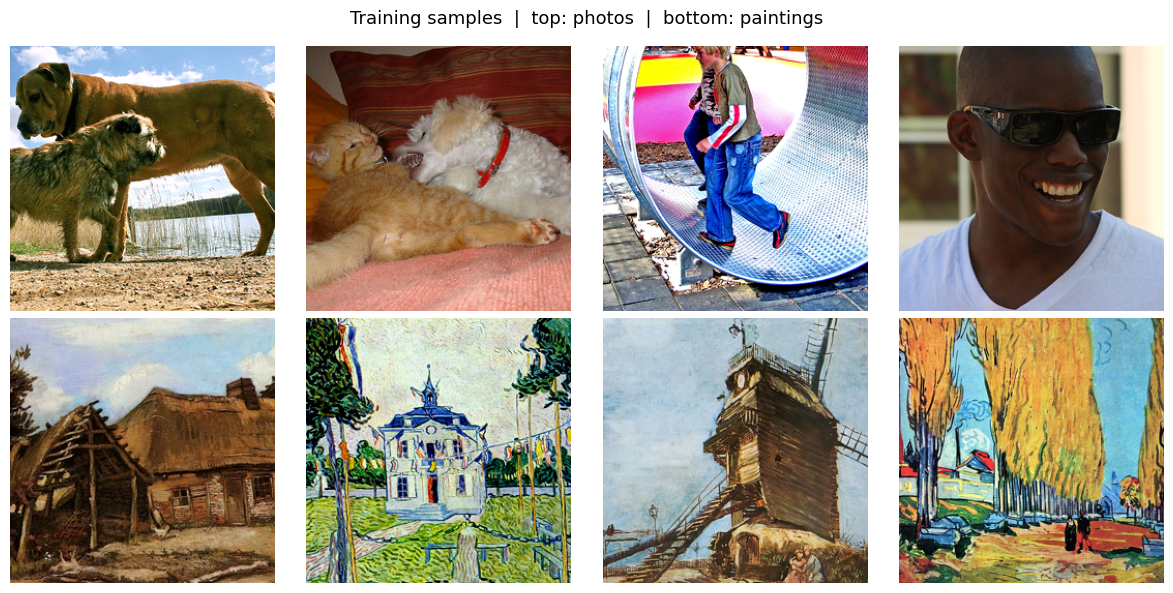

In [ ]:
# Visualise a few training samples from both domains
def denorm(t):
    '''Reverse [-1,1] normalisation to [0,1] for display.'''
    return (t * 0.5 + 0.5).clamp(0, 1)

sample_x, sample_y = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training samples  |  top: photos  |  bottom: paintings', fontsize=13)
for i in range(4):
    axes[0, i].imshow(denorm(sample_x[i]).permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(sample_y[i]).permute(1, 2, 0))
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig(EVAL_DIR / 'training_samples.png', dpi=100)
plt.show()

## 4. CycleGAN Architecture

#### Architecture Overview
- **Generator $G_{XY}$**: Photo -> Painting; ResNet-based, 9 residual blocks
- **Generator $G_{YX}$**: Painting -> Photo; ResNet-based, 9 residual blocks  
- **Discriminator $D_Y$**: real vs fake paintings
- **Discriminator $D_X$**: real vs fake photos

In [ ]:
# Building blocks 

class ResidualBlock(nn.Module):
    '''ResNet residual block with instance normalisation.'''
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x) # skip connection, output = x + F(x)


class Generator(nn.Module):
    '''
    ResNet-based Generator (Johnson et al. 2016 / Zhu et al. 2017).
    Encoder (downsample) -> Residual blocks -> Decoder (upsample).
    Uses reflection padding to avoid border artefacts.
    '''
    def __init__(self, in_channels=3, out_channels=3, n_res_blocks=9):
        super().__init__()

        # Encoder
        encoder = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
            # downsample ×2
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),
            # downsample ×2
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True),
        ]

        # Residual blocks
        res_blocks = [ResidualBlock(256) for _ in range(n_res_blocks)]

        # Decoder
        decoder = [
            # upsample ×2
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),
            # upsample ×2
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, out_channels, 7),
            nn.Tanh(),  # output in [-1, 1]
        ]

        self.model = nn.Sequential(*encoder, *res_blocks, *decoder)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    '''
    70x70 PatchGAN Discriminator.
    Classifies overlapping image patches as real/fake rather than the whole image.
    -> Using patches improves the ability to capture local texture/style.
    '''
    def __init__(self, in_channels=3, n_filters=64):
        super().__init__()

        def block(in_c, out_c, normalise=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if normalise:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels,      n_filters,     normalise=False),
            *block(n_filters,        n_filters * 2),
            *block(n_filters * 2,    n_filters * 4),
            *block(n_filters * 4,    n_filters * 8),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(n_filters * 8, 1, 4, padding=1),  # patch output
        )

    def forward(self, x):
        return self.model(x)


def weights_init(m):
    '''Initialise conv & batchnorm weights as per the CycleGAN paper.'''
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):  # check if layer is a conv layer
        nn.init.normal_(m.weight, mean=0.0, std=0.02) # initialize weight from normal distribution
        if m.bias is not None:
            nn.init.zeros_(m.bias) # initialize bias to 0
    elif isinstance(m, nn.InstanceNorm2d): # check if layer is instance norm
        if m.weight is not None:
            nn.init.normal_(m.weight, mean=1.0, std=0.02) # initialize weight from normal distribution
        if m.bias is not None:
            nn.init.zeros_(m.bias) # initialize bias to 0


# Create models / networks
G_photo2paint = Generator(n_res_blocks=N_RES_BLOCKS).to(DEVICE)  # X -> Y
G_paint2photo = Generator(n_res_blocks=N_RES_BLOCKS).to(DEVICE)  # Y -> X
D_paint = PatchDiscriminator().to(DEVICE)                        # judges Y domain
D_photo = PatchDiscriminator().to(DEVICE)                        # judges X domain

for model in [G_photo2paint, G_paint2photo, D_paint, D_photo]:
    model.apply(weights_init)

total_params = lambda m: sum(p.numel() for p in m.parameters())
print(f'Generator params      : {total_params(G_photo2paint):,}')
print(f'Discriminator params  : {total_params(D_paint):,}')

Generator params      : 11,378,179
Discriminator params  : 2,764,737


## 5. Loss Functions, Optimisers & Helpers


#### Loss functions
- **Adversarial loss** (LSGAN): Makes generated images realistic
- **Cycle-consistency loss**: F(G(x)) ≈ x and G(F(y)) ≈ y
- **Identity loss**: G(y) ≈ y and F(x) ≈ x (stabilises colour)

In [ ]:
# Losses
criterion_GAN = nn.MSELoss()      # LSGAN: more stable than BCE
criterion_cycle = nn.L1Loss()     # cycle-consistency
criterion_identity = nn.L1Loss()  # identity mapping


# Optimisers
opt_G = optim.Adam(
    itertools.chain(G_photo2paint.parameters(), G_paint2photo.parameters()),
    lr=LR, betas=(0.5, 0.999)
)
opt_D_paint = optim.Adam(D_paint.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D_photo = optim.Adam(D_photo.parameters(), lr=LR, betas=(0.5, 0.999))


# Learning-rate scheduler: constant then linear decay
def lambda_lr(epoch):
    '''Learning rate schedule, constant at first and from a specified epoch then linearly decays to 0.'''
    if epoch < DECAY_EPOCH:
        return 1.0
    return max(0.0, 1.0 - (epoch - DECAY_EPOCH) / (NUM_EPOCHS - DECAY_EPOCH))

scheduler_G = optim.lr_scheduler.LambdaLR(opt_G, lambda_lr)
scheduler_D_paint = optim.lr_scheduler.LambdaLR(opt_D_paint, lambda_lr)
scheduler_D_photo = optim.lr_scheduler.LambdaLR(opt_D_photo, lambda_lr)


# Image history buffer (stabilises discriminator training)
class ImagePool:
    '''
    Stores a rolling buffer of previously generated images.
    Discriminators are updated on a mix of new & old fakes (generated images).
    This prevents the generator from exploiting discriminator "memory".
    '''
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []

    def query(self, images): 
        if self.pool_size == 0:
            return images
        return_images = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.pool_size:
                self.images.append(img)
                return_images.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.pool_size - 1)
                    tmp = self.images[idx].clone()
                    self.images[idx] = img
                    return_images.append(tmp)
                else:
                    return_images.append(img)
        return torch.cat(return_images, dim=0)

pool_paint = ImagePool(POOL_SIZE)
pool_photo = ImagePool(POOL_SIZE)

print('Losses, optimisers and schedulers ready.')

Losses, optimisers and schedulers ready.


## 6. Training Loop

In [ ]:
history = {'loss_G': [], 'loss_D': [], 'loss_cycle': [], 'loss_identity': []}


def train_one_epoch(epoch: int) -> dict:
    G_photo2paint.train(); G_paint2photo.train()
    D_paint.train(); D_photo.train()

    epoch_losses = {'G': 0, 'D': 0, 'cycle': 0, 'identity': 0}

    for real_X, real_Y in train_loader:
        real_X = real_X.to(DEVICE)   # photos
        real_Y = real_Y.to(DEVICE)   # paintings
        bs = real_X.size(0)
        real_label = torch.ones(bs, 1, 30, 30, device=DEVICE)
        fake_label = torch.zeros(bs, 1, 30, 30, device=DEVICE)

        # Train Generators 
        opt_G.zero_grad()

        # Identity losses
        '''G_XY(y) ≈ y and G_YX(x) ≈ x'''
        loss_id_Y = criterion_identity(G_photo2paint(real_Y), real_Y)
        loss_id_X = criterion_identity(G_paint2photo(real_X), real_X)
        loss_identity = (loss_id_X + loss_id_Y) * LAMBDA_IDENTITY * 0.5

        # GAN adversarial losses
        '''Discriminator should believe generated images are real.'''
        fake_Y = G_photo2paint(real_X)  # photo -> painting
        pred_fake_Y = D_paint(fake_Y)
        # adjust label shape to match discriminator output
        rl = torch.ones_like(pred_fake_Y)  # real label
        loss_GAN_XY = criterion_GAN(pred_fake_Y, rl) 

        fake_X = G_paint2photo(real_Y)  # painting -> photo
        pred_fake_X = D_photo(fake_X)
        loss_GAN_YX = criterion_GAN(pred_fake_X, torch.ones_like(pred_fake_X))

        # Cycle-consistency losses
        '''A cycle should reconstruct original input image.'''
        recov_X = G_paint2photo(fake_Y)  # photo -> painting -> photo
        loss_cycle_X = criterion_cycle(recov_X, real_X)

        recov_Y = G_photo2paint(fake_X)  # painting -> photo -> painting
        loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
        loss_cycle = (loss_cycle_X + loss_cycle_Y) * LAMBDA_CYCLE # total cycle loss

        loss_G = loss_GAN_XY + loss_GAN_YX + loss_cycle + loss_identity 
        loss_G.backward()
        opt_G.step()

        # Train Discriminator D_paint
        opt_D_paint.zero_grad()
        fake_Y_pooled = pool_paint.query(fake_Y.detach())
        real_label_d = torch.ones_like(D_paint(real_Y))
        fake_label_d = torch.zeros_like(D_paint(fake_Y_pooled))
        loss_D_paint = (
            criterion_GAN(D_paint(real_Y), real_label_d) +
            criterion_GAN(D_paint(fake_Y_pooled), fake_label_d)
        ) * 0.5
        loss_D_paint.backward()
        opt_D_paint.step()

        # Train Discriminator D_photo
        opt_D_photo.zero_grad()
        fake_X_pooled = pool_photo.query(fake_X.detach())
        loss_D_photo = (
            criterion_GAN(D_photo(real_X), torch.ones_like(D_photo(real_X))) +
            criterion_GAN(D_photo(fake_X_pooled), torch.zeros_like(D_photo(fake_X_pooled)))
        ) * 0.5
        loss_D_photo.backward()
        opt_D_photo.step()

        epoch_losses['G']        += loss_G.item()
        epoch_losses['D']        += (loss_D_paint.item() + loss_D_photo.item()) / 2
        epoch_losses['cycle']    += loss_cycle.item()
        epoch_losses['identity'] += loss_identity.item()

    n = len(train_loader)
    return {k: v / n for k, v in epoch_losses.items()}


def save_sample_images(epoch: int, n: int = 4):
    '''Save a grid of (real photo | fake painting | recovered photo) triplets.'''
    G_photo2paint.eval(); G_paint2photo.eval()
    with torch.no_grad():
        xs = [eval_transform(Image.open(p).convert('RGB')).unsqueeze(0)
              for p in test_photo_paths[:n]]
        real_X = torch.cat(xs).to(DEVICE)
        fake_Y = G_photo2paint(real_X)
        recov_X = G_paint2photo(fake_Y)

        ys = [eval_transform(Image.open(p).convert('RGB')).unsqueeze(0)
              for p in test_painting_paths[:n]]
        real_Y = torch.cat(ys).to(DEVICE)
        fake_X = G_paint2photo(real_Y)
        recov_Y = G_photo2paint(fake_X)

        # Row 1: photo→painting cycle  |  Row 2: painting→photo cycle
        row1 = torch.cat([real_X, fake_Y, recov_X], dim=0)
        row2 = torch.cat([real_Y, fake_X, recov_Y], dim=0)
        grid = vutils.make_grid(torch.cat([row1, row2], dim=0),
                                nrow=n, normalize=True, value_range=(-1, 1))
        vutils.save_image(grid, SAMPLE_DIR / f'epoch_{epoch:04d}.png')


print('Training functions defined. Starting training...')

Training functions defined. Starting training...


In [ ]:
# TRAINING LOOP
SAVE_SAMPLE_EVERY = 5  # save sample images every N epochs
SAVE_MODEL_EVERY = 25  # checkpoint models every N epochs

for epoch in range(1, NUM_EPOCHS + 1):
    losses = train_one_epoch(epoch)

    history['loss_G'].append(losses['G'])
    history['loss_D'].append(losses['D'])
    history['loss_cycle'].append(losses['cycle'])
    history['loss_identity'].append(losses['identity'])

    scheduler_G.step()
    scheduler_D_paint.step()
    scheduler_D_photo.step()

    if epoch % SAVE_SAMPLE_EVERY == 0 or epoch == 1:
        save_sample_images(epoch)

    if epoch % SAVE_MODEL_EVERY == 0 or epoch == NUM_EPOCHS:
        torch.save(G_photo2paint.state_dict(), MODEL_DIR / f'G_photo2paint_ep{epoch}.pth')
        torch.save(G_paint2photo.state_dict(), MODEL_DIR / f'G_paint2photo_ep{epoch}.pth')
        torch.save(D_paint.state_dict(),       MODEL_DIR / f'D_paint_ep{epoch}.pth')
        torch.save(D_photo.state_dict(),       MODEL_DIR / f'D_photo_ep{epoch}.pth')

    if epoch % 1 == 0:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
              f'G: {losses["G"]:.4f}  D: {losses["D"]:.4f}  '
              f'Cycle: {losses["cycle"]:.4f}  ID: {losses["identity"]:.4f}  '
              f'LR: {scheduler_G.get_last_lr()[0]:.6f}')

print('Training complete.')

Epoch [  1/150]  G: 9.9062  D: 0.6108  Cycle: 6.9227  ID: 1.6532  LR: 0.000200
Epoch [  2/150]  G: 7.6126  D: 0.2843  Cycle: 5.6141  ID: 1.2832  LR: 0.000200
Epoch [  3/150]  G: 6.9449  D: 0.2584  Cycle: 5.0996  ID: 1.1608  LR: 0.000200
Epoch [  4/150]  G: 6.6430  D: 0.2598  Cycle: 4.8409  ID: 1.0979  LR: 0.000200
Epoch [  5/150]  G: 6.5736  D: 0.2517  Cycle: 4.7830  ID: 1.0842  LR: 0.000200
Epoch [  6/150]  G: 6.1600  D: 0.2443  Cycle: 4.4529  ID: 1.0191  LR: 0.000200
Epoch [  7/150]  G: 5.9182  D: 0.2463  Cycle: 4.2235  ID: 0.9699  LR: 0.000200
Epoch [  8/150]  G: 5.9975  D: 0.2367  Cycle: 4.2820  ID: 0.9838  LR: 0.000200
Epoch [  9/150]  G: 5.9679  D: 0.2320  Cycle: 4.2220  ID: 0.9746  LR: 0.000200
Epoch [ 10/150]  G: 5.8183  D: 0.2249  Cycle: 4.0693  ID: 0.9680  LR: 0.000200
Epoch [ 11/150]  G: 5.9741  D: 0.2234  Cycle: 4.1893  ID: 0.9810  LR: 0.000200
Epoch [ 12/150]  G: 5.8287  D: 0.2093  Cycle: 4.0767  ID: 0.9611  LR: 0.000200
Epoch [ 13/150]  G: 5.7380  D: 0.2074  Cycle: 4.0109

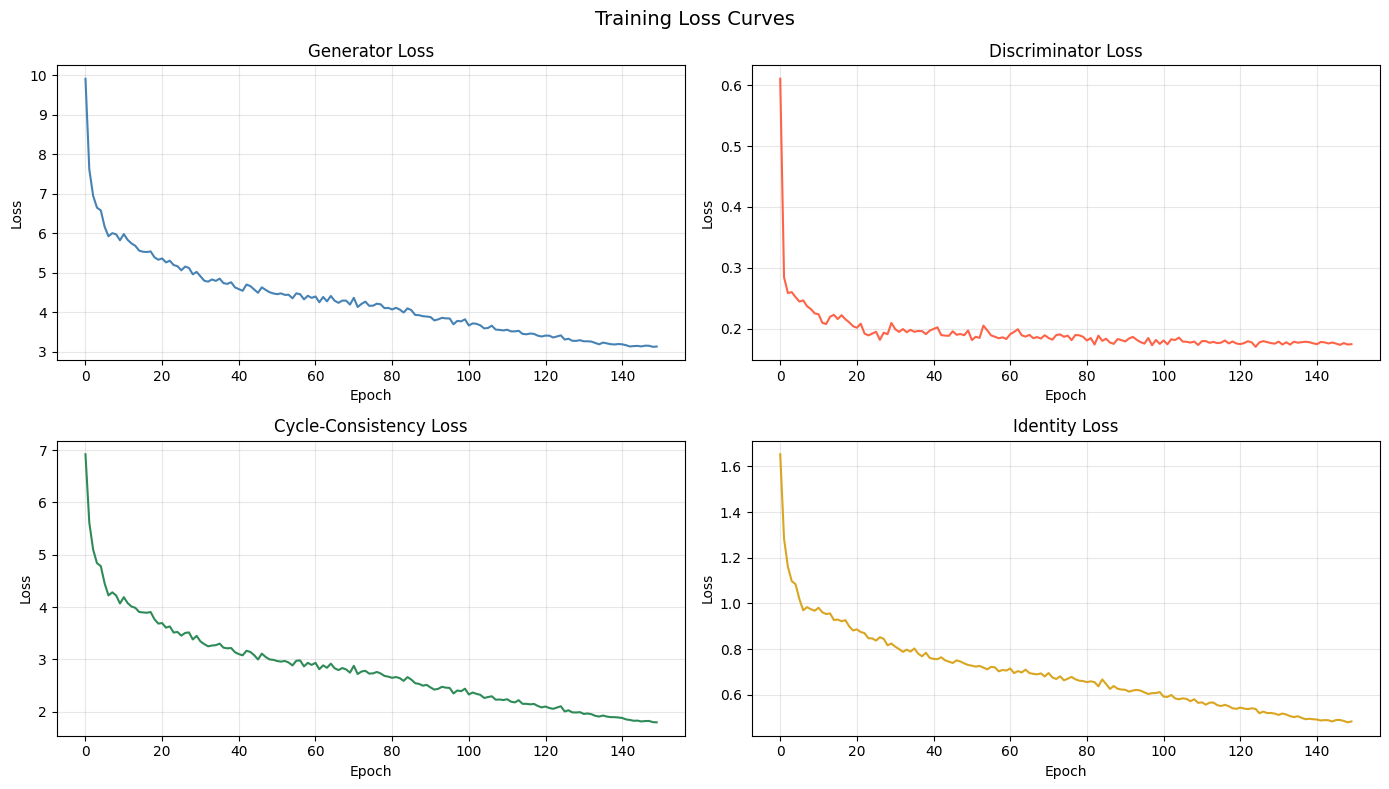

In [ ]:
# Plot training loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training Loss Curves', fontsize=14)

axes[0, 0].plot(history['loss_G'], color='steelblue')
axes[0, 0].set_title('Generator Loss')
axes[0, 1].plot(history['loss_D'], color='tomato')
axes[0, 1].set_title('Discriminator Loss')
axes[1, 0].plot(history['loss_cycle'], color='seagreen')
axes[1, 0].set_title('Cycle-Consistency Loss')
axes[1, 1].plot(history['loss_identity'], color='goldenrod')
axes[1, 1].set_title('Identity Loss')

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'loss_curves.png', dpi=120)
plt.show()

## 7. Evaluation

### Implemented metrics
| Metric | What it measures | Ideal |
|--------|-----------------|-------|
| **FID** | Statistical distance between real and generated image distributions (Inception features) | Lower |
| **LPIPS** | Perceptual similarity (deep features) — used for cycle quality | Lower |
| **SSIM** | Structural similarity (luminance, contrast, structure) — used for cycle quality | Higher |

In [ ]:
# Load best checkpoint (trained generators) for evaluation
G_photo2paint.load_state_dict(torch.load(MODEL_DIR / f'G_photo2paint_ep{NUM_EPOCHS}.pth', map_location=DEVICE))
G_paint2photo.load_state_dict(torch.load(MODEL_DIR / f'G_paint2photo_ep{NUM_EPOCHS}.pth', map_location=DEVICE))
G_photo2paint.eval(); G_paint2photo.eval()
print('Models loaded for evaluation.')

Models loaded for evaluation.


In [ ]:
# Generate & save all test images

def generate_test_images():
    '''
    For every test photo/painting, generate translated images and cycle-recovered images. 
    Save everything to EVAL_DIR and return tensors for metric computation.
    '''
    real_photos, fake_paintings, recov_photos = [], [], []
    real_paintings, fake_photos, recov_paintings = [], [], []

    (EVAL_DIR / 'fake_paintings').mkdir(exist_ok=True)
    (EVAL_DIR / 'fake_photos').mkdir(exist_ok=True)
    (EVAL_DIR / 'recovered_photos').mkdir(exist_ok=True)
    (EVAL_DIR / 'recovered_paintings').mkdir(exist_ok=True)

    with torch.no_grad():
        for i, path in enumerate(test_photo_paths):
            x = eval_transform(Image.open(path).convert('RGB')).unsqueeze(0).to(DEVICE)
            fy = G_photo2paint(x)
            rx = G_paint2photo(fy)
            real_photos.append(x); fake_paintings.append(fy); recov_photos.append(rx)
            vutils.save_image(fy, EVAL_DIR / 'fake_paintings' / f'{i:04d}.png', normalize=True, value_range=(-1,1))
            vutils.save_image(rx, EVAL_DIR / 'recovered_photos' / f'{i:04d}.png', normalize=True, value_range=(-1,1))

        for i, path in enumerate(test_painting_paths):
            y = eval_transform(Image.open(path).convert('RGB')).unsqueeze(0).to(DEVICE)
            fx = G_paint2photo(y)
            ry = G_photo2paint(fx)
            real_paintings.append(y); fake_photos.append(fx); recov_paintings.append(ry)
            vutils.save_image(fx, EVAL_DIR / 'fake_photos' / f'{i:04d}.png', normalize=True, value_range=(-1,1))
            vutils.save_image(ry, EVAL_DIR / 'recovered_paintings' / f'{i:04d}.png', normalize=True, value_range=(-1,1))

    cat = lambda lst: torch.cat(lst, dim=0)
    return {
        'real_X': cat(real_photos), 'fake_Y': cat(fake_paintings), 'recov_X': cat(recov_photos),
        'real_Y': cat(real_paintings), 'fake_X': cat(fake_photos), 'recov_Y': cat(recov_paintings),
    }

tensors = generate_test_images()
print(f'Generated {len(test_photo_paths)} photo→painting pairs and {len(test_painting_paths)} painting→photo pairs.')

Generated 100 photo→painting pairs and 100 painting→photo pairs.


In [ ]:
# FID  (Fréchet Inception Distance)
'''
FID is most reliable with many (≥ ~ 2 000) images. With small test sets it gives a rough indication only. 
Since we only train with small datasets, KID could be more reliable if precision matters.
'''

inception = inception_v3(pretrained=True, transform_input=False).to(DEVICE)
inception.fc = nn.Identity() # remove classification head -> 2048-d features
inception.eval()


def get_inception_features(images: torch.Tensor, batch_size=16) -> np.ndarray:
    '''Run images through Inception-v3 and return feature vectors.'''
    resize = T.Resize((299, 299))
    feats = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = resize(images[i: i + batch_size].to(DEVICE))
            # Inception expects [0,1] input; our images are [-1,1]
            batch = (batch + 1) / 2
            feats.append(inception(batch).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(feats_real: np.ndarray, feats_fake: np.ndarray) -> float:
    mu1, sigma1 = feats_real.mean(0), np.cov(feats_real, rowvar=False)
    mu2, sigma2 = feats_fake.mean(0), np.cov(feats_fake, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))
    return fid


print('Computing FID scores...')
feats_real_Y = get_inception_features(tensors['real_Y'])   # real paintings
feats_fake_Y = get_inception_features(tensors['fake_Y'])   # generated paintings
feats_real_X = get_inception_features(tensors['real_X'])   # real photos
feats_fake_X = get_inception_features(tensors['fake_X'])   # generated photos

fid_XY = compute_fid(feats_real_Y, feats_fake_Y)
fid_YX = compute_fid(feats_real_X, feats_fake_X)
print(f'FID  photo → painting : {fid_XY:.2f}')
print(f'FID  painting → photo : {fid_YX:.2f}')
print('  (lower is better; <50 is reasonable, <30 is good for artistic style transfer)')

Computing FID scores...
FID  photo → painting : 245.69
FID  painting → photo : 284.40
  (lower is better; <50 is reasonable, <30 is good for artistic style transfer)


In [ ]:
# LPIPS  (Learned Perceptual Image Patch Similarity)
'''Applied to the CYCLE QUALITY: how well the recovered image matches the original.'''
lpips_fn = lpips.LPIPS(net='vgg').to(DEVICE)


def compute_lpips_batch(originals: torch.Tensor, reconstructed: torch.Tensor) -> float:
    '''Mean LPIPS over a batch. Inputs expected in [-1, 1].'''
    scores = []
    with torch.no_grad():
        for i in range(len(originals)):
            a = originals[i].unsqueeze(0).to(DEVICE)
            b = reconstructed[i].unsqueeze(0).to(DEVICE)
            scores.append(lpips_fn(a, b).item())
    return float(np.mean(scores))


lpips_cycle_X = compute_lpips_batch(tensors['real_X'], tensors['recov_X'])
lpips_cycle_Y = compute_lpips_batch(tensors['real_Y'], tensors['recov_Y'])

print(f'LPIPS  photo cycle  (photo → painting → photo) : {lpips_cycle_X:.4f}')
print(f'LPIPS  painting cycle (painting → photo → painting) : {lpips_cycle_Y:.4f}')
print('  (lower is better; <0.10 excellent, <0.20 good, <0.35 acceptable)')

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /Users/ebbagregefalk/Library/CloudStorage/OneDrive-Chalmers/Chalmers/M1/LP4/TIF360- Advanced machine learning with neural networks/03_Python-TIF360/venv_TIF360/lib/python3.13/site-packages/lpips/weights/v0.1/vgg.pth
LPIPS  photo cycle  (photo → painting → photo) : 0.2872
LPIPS  painting cycle (painting → photo → painting) : 0.3205
  (lower is better; <0.10 excellent, <0.20 good, <0.35 acceptable)


In [ ]:
# SSIM  (Structural Similarity Index Measure)
'''Applied to the cycle: original vs recovered image.'''

def tensor_to_numpy_uint8(t: torch.Tensor) -> np.ndarray:
    '''Convert [-1,1] tensor (C,H,W) → uint8 numpy (H,W,C).'''
    img = ((t.cpu().numpy().transpose(1, 2, 0) + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    return img


def compute_ssim_batch(originals: torch.Tensor, reconstructed: torch.Tensor) -> float:
    scores = []
    for i in range(len(originals)):
        a = tensor_to_numpy_uint8(originals[i])
        b = tensor_to_numpy_uint8(reconstructed[i])
        score = ssim_metric(a, b, multichannel=True, channel_axis=2,
                            data_range=255)
        scores.append(score)
    return float(np.mean(scores))


ssim_cycle_X = compute_ssim_batch(tensors['real_X'], tensors['recov_X'])
ssim_cycle_Y = compute_ssim_batch(tensors['real_Y'], tensors['recov_Y'])

print(f'SSIM  photo cycle    (photo → painting → photo) : {ssim_cycle_X:.4f}')
print(f'SSIM  painting cycle (painting → photo → painting) : {ssim_cycle_Y:.4f}')
print('  (higher is better; >0.70 good, >0.80 excellent)')

SSIM  photo cycle    (photo → painting → photo) : 0.8001
SSIM  painting cycle (painting → photo → painting) : 0.7540
  (higher is better; >0.70 good, >0.80 excellent)


In [ ]:
# STYLE LOSS  (Gram matrix distance; how well style is transferred)
'''Uses VGG-16 intermediate activations, same principle as neural style transfer.'''
import torchvision.models as tvm

vgg = tvm.vgg16(pretrained=True).features[:23].to(DEVICE).eval()
for p in vgg.parameters():
    p.requires_grad_(False)


def gram_matrix(feat: torch.Tensor) -> torch.Tensor:
    b, c, h, w = feat.shape
    f = feat.view(b, c, -1)
    return torch.bmm(f, f.transpose(1, 2)) / (c * h * w)


def style_distance(real_paintings: torch.Tensor, fake_paintings: torch.Tensor,
                   batch_size=8) -> float:
    '''Mean Frobenius norm between Gram matrices of real and generated paintings.'''
    vgg_norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    scores = []
    n = min(len(real_paintings), len(fake_paintings))
    with torch.no_grad():
        for i in range(0, n, batch_size):
            r = ((real_paintings[i:i+batch_size].to(DEVICE) + 1) / 2)
            f = ((fake_paintings[i:i+batch_size].to(DEVICE) + 1) / 2)
            r = torch.stack([vgg_norm(img) for img in r])
            f = torch.stack([vgg_norm(img) for img in f])
            gram_r = gram_matrix(vgg(r))
            gram_f = gram_matrix(vgg(f))
            scores.append((gram_r - gram_f).pow(2).mean().item())
    return float(np.mean(scores))


style_dist = style_distance(tensors['real_Y'], tensors['fake_Y'])
print(f'Style (Gram) distance  real paintings vs generated paintings : {style_dist:.6f}')
print('  (lower is better; measures how well the artistic style is captured)')

Style (Gram) distance  real paintings vs generated paintings : 0.000001
  (lower is better; measures how well the artistic style is captured)


In [ ]:
# Summary table & save
results = {
    'Artist'           : ARTIST,
    'Epochs'           : NUM_EPOCHS,
    'Num photos'       : NUM_PHOTOS,
    'Num paintings'    : NUM_PAINTINGS,
    'FID photo→paint'  : round(fid_XY, 2),
    'FID paint→photo'  : round(fid_YX, 2),
    'LPIPS cycle-X'    : round(lpips_cycle_X, 4),
    'LPIPS cycle-Y'    : round(lpips_cycle_Y, 4),
    'SSIM cycle-X'     : round(ssim_cycle_X, 4),
    'SSIM cycle-Y'     : round(ssim_cycle_Y, 4),
    'Style (Gram) dist': round(style_dist, 6),
}

import json
with open(EVAL_DIR / 'metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print('\n========  EVALUATION SUMMARY  ========')
for k, v in results.items():
    print(f'  {k:<26} {v}')
print(f'\nAll results saved to {EVAL_DIR}/')


========  EVALUATION SUMMARY  ========
  Artist                     Vincent_van_Gogh
  Epochs                     150
  Num photos                 400
  Num paintings              400
  FID photo→paint            245.69
  FID paint→photo            284.4
  LPIPS cycle-X              0.2872
  LPIPS cycle-Y              0.3205
  SSIM cycle-X               0.8001
  SSIM cycle-Y               0.754
  Style (Gram) dist          1e-06

All results saved to /Users/ebbagregefalk/Library/CloudStorage/OneDrive-Chalmers/Chalmers/M1/LP4/TIF360- Advanced machine learning with neural networks/03_Python-TIF360/Project_L/output/Vincent_van_Gogh/evaluation/


## 8. Visualise Results

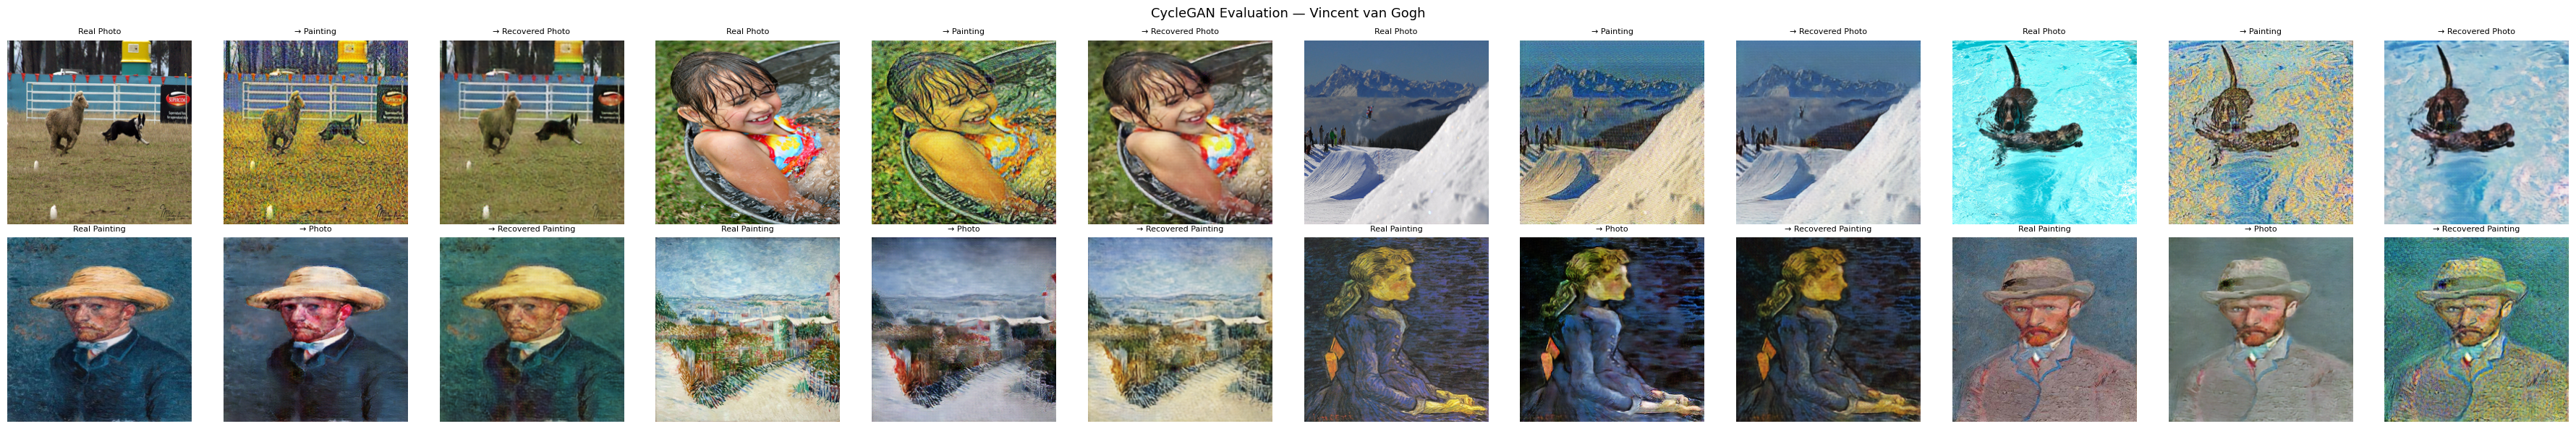

In [18]:
def show_cycle(real_X, fake_Y, recov_X, real_Y, fake_X, recov_Y, n=4):
    fig, axes = plt.subplots(2, n * 3, figsize=(n * 9, 6))
    titles_top = ['Real Photo', '→ Painting', '→ Recovered Photo'] * n
    titles_bot = ['Real Painting', '→ Photo', '→ Recovered Painting'] * n

    col = 0
    for i in range(n):
        for img in [real_X[i], fake_Y[i], recov_X[i]]:
            axes[0, col].imshow(denorm(img.cpu()).permute(1, 2, 0))
            axes[0, col].set_title(titles_top[col], fontsize=8)
            axes[0, col].axis('off')
            col += 1
    col = 0
    for i in range(n):
        for img in [real_Y[i], fake_X[i], recov_Y[i]]:
            axes[1, col].imshow(denorm(img.cpu()).permute(1, 2, 0))
            axes[1, col].set_title(titles_bot[col], fontsize=8)
            axes[1, col].axis('off')
            col += 1

    fig.suptitle(f'CycleGAN Evaluation — {ARTIST.replace("_", " ")}', fontsize=13)
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'cycle_visualisation.png', dpi=120, bbox_inches='tight')
    plt.show()


show_cycle(
    tensors['real_X'][:4], tensors['fake_Y'][:4], tensors['recov_X'][:4],
    tensors['real_Y'][:4], tensors['fake_X'][:4], tensors['recov_Y'][:4],
)